# Talc Domain Generalization Experiment

This notebook trains a talc segmenter with stronger domain augmentations and saves all outputs inside this notebook directory.

In [1]:
from pathlib import Path
import csv
import json
import math
import shutil

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision.transforms.functional as TF
from PIL import Image, ImageDraw, ImageOps
from tqdm.auto import tqdm

ROOT = Path.cwd()

def find_project_root():
    markers = [
        Path('configs') / 'segmentation' / 'talc_dataset.json',
        Path('data') / 'talc_dataset_builder.py',
    ]
    candidates = [ROOT, *ROOT.parents, Path(r'D:\Nornikel-2026-Shlif-Case')]
    for candidate in candidates:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError(
        'Could not find project root. Set PROJECT_ROOT manually to D:/Nornikel-2026-Shlif-Case.'
    )

PROJECT_ROOT = find_project_root()
NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks' / 'talc_domain_generalization'
OUT = NOTEBOOK_DIR / 'outputs'
RUN_DIR = OUT / 'runs' / 'talc_segmenter_domain_aug'
PLOTS_DIR = OUT / 'plots'
OVERLAY_DIR = OUT / '01_markup_plus_prediction'
TALC_MASK_DIR = OUT / '02_talc_images_model_masks'
NONTALC_MASK_DIR = OUT / '03_nontalc_nonempty_model_masks'

for path in [RUN_DIR, PLOTS_DIR, OVERLAY_DIR, TALC_MASK_DIR, NONTALC_MASK_DIR]:
    path.mkdir(parents=True, exist_ok=True)

import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

def project_path(value):
    path = Path(value)
    return str(path if path.is_absolute() else PROJECT_ROOT / path)

def absolutize_cfg_paths(cfg, keys):
    cfg = dict(cfg)
    for key in keys:
        if key in cfg and cfg[key]:
            cfg[key] = project_path(cfg[key])
    return cfg

print('PROJECT_ROOT =', PROJECT_ROOT)
print('OUT =', OUT)

PROJECT_ROOT = D:\Nornikel-2026-Shlif-Case
OUT = D:\Nornikel-2026-Shlif-Case\notebooks\talc_domain_generalization\outputs


## 1. Build talc segmentation manifest

Run this cell when masks or source data changed.

In [2]:
from hydra.json_config import JsonConfig
from data.talc_dataset_builder import TalcSegmentationDatasetBuilder
from data.weak_masks import WeakMaskBatchExporter

weak_cfg = JsonConfig.load(PROJECT_ROOT / 'configs' / 'data' / 'weak_talc_masks.json').to_dict()
weak_cfg = absolutize_cfg_paths(weak_cfg, ['input_root', 'output_root'])
weak_report = Path(weak_cfg['output_root']) / 'weak_mask_report.csv'
if not weak_report.exists():
    print('weak_mask_report.csv not found, extracting weak masks...')
    exporter = WeakMaskBatchExporter.from_config(weak_cfg)
    results = exporter.export(weak_cfg['input_root'], weak_cfg['output_root'])
    weak_report.parent.mkdir(parents=True, exist_ok=True)
    with weak_report.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=list(results[0].__dict__.keys()) if results else [])
        if results:
            writer.writeheader()
            writer.writerows([item.__dict__ for item in results])
    print(f'extracted weak masks: {len(results)} -> {weak_report}')
else:
    print('using existing weak report:', weak_report)

dataset_cfg = JsonConfig.load(PROJECT_ROOT / 'configs' / 'segmentation' / 'talc_dataset.json').to_dict()
dataset_cfg = absolutize_cfg_paths(
    dataset_cfg,
    ['manifest_csv', 'weak_mask_report_csv', 'manual_mask_dir', 'output_csv', 'negative_mask_dir'],
)
builder = TalcSegmentationDatasetBuilder(dataset_cfg)
rows = builder.build()
df_talc_dataset = pd.DataFrame(rows)
display(df_talc_dataset.groupby(['subset', 'sample_type']).size().rename('n').reset_index())
display(df_talc_dataset.groupby(['subset', 'sample_type'])['foreground_fraction'].agg(['min', 'mean', 'max']).reset_index())

using existing weak report: D:\Nornikel-2026-Shlif-Case\artifacts\weak_masks\talc\weak_mask_report.csv


,subset,sample_type,n
0,train,negative_zero,67
1,train,positive_manual,34
2,val,negative_zero,17
3,val,positive_manual,8


,subset,sample_type,min,mean,max
0,train,negative_zero,0.000000,0.000000,0.000000
1,train,positive_manual,0.041141,0.287624,0.620901
2,val,negative_zero,0.000000,0.000000,0.000000
3,val,positive_manual,0.042552,0.262367,0.460014


## 2. Train with stronger domain augmentations

In [3]:
from trainers.talc_segmentation_trainer import TalcSegmentationTrainer

config_path = PROJECT_ROOT / 'configs' / 'segmentation' / 'talc_segmenter_domain_aug.json'
cfg = JsonConfig.load(config_path).to_dict()
cfg = absolutize_cfg_paths(cfg, ['dataset_csv'])
cfg['run_dir'] = str(RUN_DIR)
cfg['mlflow']['enabled'] = False

# Quick debug run example:
# cfg['trainer']['epochs'] = 2

(RUN_DIR / 'resolved_config.json').write_text(json.dumps(cfg, ensure_ascii=False, indent=2), encoding='utf-8')
summary = TalcSegmentationTrainer(cfg).fit()
summary

D:\Nornikel-2026-Shlif-Case\trainers\talc_segmentation_trainer.py:69: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(


talc epochs:   0%|          | 0/34 [00:00<?, ?epoch/s]

train talc 1:   0%|          | 0/26 [00:00<?, ?batch/s]

D:\Nornikel-2026-Shlif-Case\trainers\talc_segmentation_trainer.py:131: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.scaler.is_enabled()):


val talc 1:   0%|          | 0/7 [00:00<?, ?batch/s]

...

train talc 34:   0%|          | 0/26 [00:00<?, ?batch/s]

D:\Nornikel-2026-Shlif-Case\trainers\talc_segmentation_trainer.py:131: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.scaler.is_enabled()):


val talc 34:   0%|          | 0/7 [00:00<?, ?batch/s]

D:\Nornikel-2026-Shlif-Case\trainers\talc_segmentation_trainer.py:131: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.scaler.is_enabled()):


{'best_val_dice': 0.8892789268493653, 'epochs': 34}

## 3. Training curves

,epoch,train_loss,train_dice,train_f1,train_iou,train_fraction_mae,train_roc_auc,val_loss,val_dice,val_f1,val_iou,val_fraction_mae,val_roc_auc
29,30,0.520380,0.412869,0.412869,0.368203,0.065030,0.802129,0.640334,0.768628,0.768628,0.718255,0.079998,0.889878
30,31,0.515758,0.491001,0.491001,0.441618,0.060188,0.840217,0.557985,0.852042,0.852042,0.801837,0.042931,0.857342
31,32,0.512639,0.422826,0.422826,0.378826,0.066109,0.841876,0.509096,0.868371,0.868371,0.819010,0.024181,0.845601
32,33,0.490352,0.566754,0.566754,0.517306,0.043044,0.882089,0.521674,0.867209,0.867209,0.819388,0.040425,0.875019
33,34,0.513600,0.479773,0.479773,0.437923,0.064973,0.839921,0.532270,0.870628,0.870628,0.822275,0.025005,0.848616


WindowsPath('D:/Nornikel-2026-Shlif-Case/notebooks/talc_domain_generalization/outputs/plots/training_curves.png')

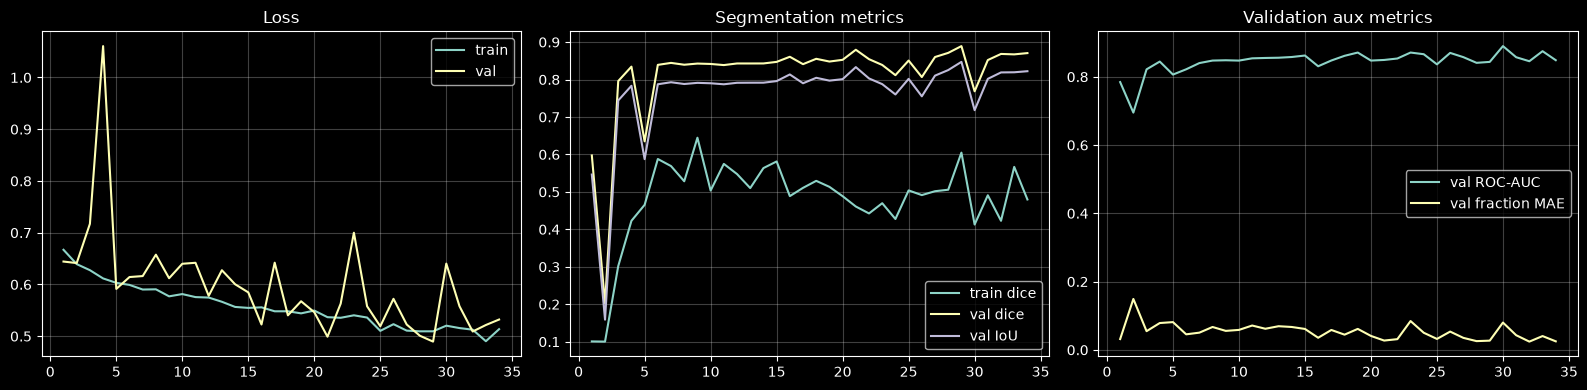

In [4]:
history_path = RUN_DIR / 'history.csv'
history = pd.read_csv(history_path)
display(history.tail())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history['epoch'], history['train_loss'], label='train')
axes[0].plot(history['epoch'], history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['epoch'], history['train_dice'], label='train dice')
axes[1].plot(history['epoch'], history['val_dice'], label='val dice')
axes[1].plot(history['epoch'], history['val_iou'], label='val IoU')
axes[1].set_title('Segmentation metrics')
axes[1].legend()

axes[2].plot(history['epoch'], history['val_roc_auc'], label='val ROC-AUC')
axes[2].plot(history['epoch'], history['val_fraction_mae'], label='val fraction MAE')
axes[2].set_title('Validation aux metrics')
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
plot_path = PLOTS_DIR / 'training_curves.png'
fig.savefig(plot_path, dpi=160)
plot_path

## 4. Load best checkpoint and helpers

In [12]:
from models.segmentation import SegmentationFactory
from data.manifest import read_manifest

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT = RUN_DIR / 'best.pt'
MASK_THRESHOLD = 0.5
NONTALC_MIN_FRACTION = 0.0005

checkpoint = torch.load(CHECKPOINT, map_location=DEVICE)
model_cfg = checkpoint['config']
image_size = model_cfg['data']['image_size']
model = SegmentationFactory.create(model_cfg['model']).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

def safe_name(rel_path):
    return '__'.join(Path(rel_path).parts).replace(' ', '_')

def read_rgb(path):
    return ImageOps.exif_transpose(Image.open(project_path(path))).convert('RGB')

def predict_prob(image):
    resized = TF.resize(image, [image_size, image_size])
    tensor = TF.to_tensor(resized)
    tensor = TF.normalize(tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
    with torch.no_grad():
        prob = torch.sigmoid(model(tensor.unsqueeze(0).to(DEVICE)))[0, 0].float().cpu().numpy()
    return prob

def resize_prob_to_image(prob, image):
    return cv2.resize(prob, image.size, interpolation=cv2.INTER_CUBIC)

def overlay_markup_prediction(image, gt_mask, pred_mask, alpha=0.45):
    rgb = np.asarray(image).copy()
    gt = gt_mask > 0
    pred = pred_mask > 0
    color = np.zeros_like(rgb)
    color[gt & ~pred] = (40, 210, 80)
    color[pred & ~gt] = (235, 60, 50)
    color[gt & pred] = (245, 220, 60)
    out = rgb.copy()
    mask = gt | pred
    out[mask] = (rgb[mask] * (1 - alpha) + color[mask] * alpha).astype(np.uint8)
    return Image.fromarray(out)

def overlay_prediction(image, pred_mask, alpha=0.45):
    rgb = np.asarray(image).copy()
    pred = pred_mask > 0
    color = np.zeros_like(rgb)
    color[pred] = (235, 60, 50)
    out = rgb.copy()
    out[pred] = (rgb[pred] * (1 - alpha) + color[pred] * alpha).astype(np.uint8)
    return Image.fromarray(out)

print('device:', DEVICE)
print('checkpoint:', CHECKPOINT)

device: cuda
checkpoint: D:\Nornikel-2026-Shlif-Case\notebooks\talc_domain_generalization\outputs\runs\talc_segmenter_domain_aug\best.pt


## 5. Save markup + prediction overlays

Colors: green = manual mask only, red = prediction only, yellow = intersection.

In [13]:
for old in OVERLAY_DIR.glob('*'):
    if old.is_file():
        old.unlink()

seg_rows = list(csv.DictReader(open(project_path(model_cfg['dataset_csv']), encoding='utf-8')))
report_rows = []
for row in tqdm(seg_rows, desc='markup + prediction'):
    image = read_rgb(row['image_path'])
    prob = resize_prob_to_image(predict_prob(image), image)
    pred_mask = (prob >= MASK_THRESHOLD).astype(np.uint8) * 255
    gt = cv2.imdecode(np.fromfile(row['mask_path'], dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
    gt = cv2.resize(gt, image.size, interpolation=cv2.INTER_NEAREST)
    name = f"{row['subset']}__{row['sample_type']}__{safe_name(row['rel_path'])}"
    out_path = OVERLAY_DIR / f"{Path(name).stem}_markup_pred.jpg"
    overlay_markup_prediction(image, gt, pred_mask).save(out_path, quality=92)
    report_rows.append({
        'subset': row['subset'],
        'sample_type': row['sample_type'],
        'rel_path': row['rel_path'],
        'gt_fraction': float((gt > 0).mean()),
        'pred_fraction': float((pred_mask > 0).mean()),
        'overlay_path': str(out_path),
    })
pd.DataFrame(report_rows).to_csv(OVERLAY_DIR / 'index.csv', index=False)
display(pd.DataFrame(report_rows).groupby(['subset', 'sample_type'])[['gt_fraction', 'pred_fraction']].mean())

markup + prediction:   0%|          | 0/126 [00:00<?, ?it/s]

gt_fraction  pred_fraction
subset sample_type                                
train  negative_zero       0.000000       0.000002
       positive_manual     0.287624       0.235923
val    negative_zero       0.000000       0.000000
       positive_manual     0.262367       0.218619

## 6. Save model masks for all talc images

In [10]:
for old in TALC_MASK_DIR.glob('*'):
    if old.is_file():
        old.unlink()

manifest_rows = [r for r in read_manifest(PROJECT_ROOT / 'artifacts' / 'manifests' / 'nornikel_manifest.csv') if r.get('source') == 'classification' and r.get('label') == 'talc']
report_rows = []
for row in tqdm(manifest_rows, desc='talc image masks'):
    image = read_rgb(row['path'])
    prob = resize_prob_to_image(predict_prob(image), image)
    mask = (prob >= MASK_THRESHOLD).astype(np.uint8) * 255
    name = safe_name(row['rel_path'])
    mask_path = TALC_MASK_DIR / f"{Path(name).stem}_mask.png"
    overlay_path = TALC_MASK_DIR / f"{Path(name).stem}_overlay.jpg"
    cv2.imencode('.png', mask)[1].tofile(str(mask_path))
    overlay_prediction(image, mask).save(overlay_path, quality=92)
    report_rows.append({
        'rel_path': row['rel_path'],
        'pred_fraction': float((mask > 0).mean()),
        'mask_path': str(mask_path),
        'overlay_path': str(overlay_path),
    })
df_talc_pred = pd.DataFrame(report_rows)
df_talc_pred.to_csv(TALC_MASK_DIR / 'index.csv', index=False)
display(df_talc_pred['pred_fraction'].describe())

talc image masks:   0%|          | 0/87 [00:00<?, ?it/s]

count    87.000000
mean      0.000003
std       0.000016
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.000132
Name: pred_fraction, dtype: float64

## 7. Save model masks for non-talc images with non-empty prediction

In [11]:
for old in NONTALC_MASK_DIR.glob('*'):
    if old.is_file():
        old.unlink()

manifest_rows = [r for r in read_manifest(PROJECT_ROOT / 'artifacts' / 'manifests' / 'nornikel_manifest.csv') if r.get('source') == 'classification' and r.get('label') in {'ordinary', 'thin'}]
report_rows = []
for row in tqdm(manifest_rows, desc='non-talc nonempty masks'):
    image = read_rgb(row['path'])
    prob = resize_prob_to_image(predict_prob(image), image)
    mask = (prob >= MASK_THRESHOLD).astype(np.uint8) * 255
    fraction = float((mask > 0).mean())
    if fraction < NONTALC_MIN_FRACTION:
        continue
    name = f"{row['label']}__{safe_name(row['rel_path'])}"
    mask_path = NONTALC_MASK_DIR / f"{Path(name).stem}_mask.png"
    overlay_path = NONTALC_MASK_DIR / f"{Path(name).stem}_overlay.jpg"
    cv2.imencode('.png', mask)[1].tofile(str(mask_path))
    overlay_prediction(image, mask).save(overlay_path, quality=92)
    report_rows.append({
        'label': row['label'],
        'rel_path': row['rel_path'],
        'pred_fraction': fraction,
        'mask_path': str(mask_path),
        'overlay_path': str(overlay_path),
    })
df_nontalc_pred = pd.DataFrame(report_rows).sort_values('pred_fraction', ascending=False)
df_nontalc_pred.to_csv(NONTALC_MASK_DIR / 'index.csv', index=False)
display(df_nontalc_pred.head(30))
display(df_nontalc_pred['pred_fraction'].describe() if len(df_nontalc_pred) else 'No non-empty non-talc masks')

non-talc nonempty masks:   0%|          | 0/915 [00:00<?, ?it/s]

,label,rel_path,pred_fraction,mask_path,overlay_path
4,ordinary,"Задача 3. Скажи мне, кто твой шлиф/Фото руд по...",0.002503,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...
7,thin,"Задача 3. Скажи мне, кто твой шлиф/Фото руд по...",0.002460,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...
5,thin,"Задача 3. Скажи мне, кто твой шлиф/Фото руд по...",0.001923,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...
6,thin,"Задача 3. Скажи мне, кто твой шлиф/Фото руд по...",0.001060,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...
8,thin,"Задача 3. Скажи мне, кто твой шлиф/Фото руд по...",0.000940,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...
0,ordinary,"Задача 3. Скажи мне, кто твой шлиф/Фото руд по...",0.000779,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...
2,ordinary,"Задача 3. Скажи мне, кто твой шлиф/Фото руд по...",0.000673,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...
1,ordinary,"Задача 3. Скажи мне, кто твой шлиф/Фото руд по...",0.000641,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...
3,ordinary,"Задача 3. Скажи мне, кто твой шлиф/Фото руд по...",0.000521,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...,D:\Nornikel-2026-Shlif-Case\notebooks\talc_dom...


count    9.000000
mean     0.001278
std      0.000796
min      0.000521
25%      0.000673
50%      0.000940
75%      0.001923
max      0.002503
Name: pred_fraction, dtype: float64